# A/B Testing Notebook

This notebook shows a A/B test.

We compare two groups:

- **Group A**: Control group
- **Group B**: Treatment group

The goal is to check whether Group B has a better conversion rate than Group A.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 2. Create simple sample data

Here we create fake A/B testing data.

- `group` tells whether the user is in A or B.
- `converted` tells whether the user converted.
  - `1` means converted
  - `0` means not converted

In [2]:
np.random.seed(42)

# Number of users in each group
n_A = 1000
n_B = 1000

# Conversion rates
conversion_rate_A = 0.10   # 10%
conversion_rate_B = 0.13   # 13%

# Create data
group_A = pd.DataFrame({
    "group": "A",
    "converted": np.random.binomial(1, conversion_rate_A, n_A)
})

group_B = pd.DataFrame({
    "group": "B",
    "converted": np.random.binomial(1, conversion_rate_B, n_B)
})

df = pd.concat([group_A, group_B], ignore_index=True)

df.head()

,group,converted
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0


## 3. Calculate conversion rate for each group

In [3]:
summary = df.groupby("group")["converted"].agg(["count", "sum", "mean"])

summary = summary.rename(columns={
    "count": "users",
    "sum": "conversions",
    "mean": "conversion_rate"
})

summary

,users,conversions,conversion_rate
group,,,
A,1000,100,0.100
B,1000,131,0.131


## 4. Calculate lift

Lift tells us how much better Group B is compared to Group A.

In [4]:
rate_A = summary.loc["A", "conversion_rate"]
rate_B = summary.loc["B", "conversion_rate"]

absolute_lift = rate_B - rate_A
relative_lift = absolute_lift / rate_A

print(f"Conversion rate A: {rate_A:.2%}")
print(f"Conversion rate B: {rate_B:.2%}")
print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.2%}")

Conversion rate A: 10.00%
Conversion rate B: 13.10%
Absolute lift: 3.10%
Relative lift: 31.00%


## 5. Visualize conversion rates

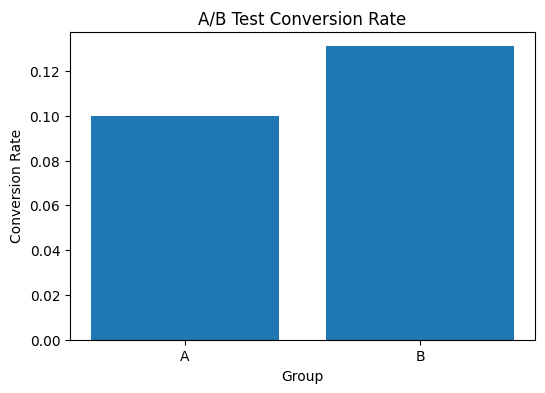

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(summary.index, summary["conversion_rate"])

plt.title("A/B Test Conversion Rate")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

## 6. Run statistical test

We use a **two-proportion z-test**.

This checks whether the difference between Group A and Group B is statistically significant.

In [6]:
conversions_A = summary.loc["A", "conversions"]
conversions_B = summary.loc["B", "conversions"]

users_A = summary.loc["A", "users"]
users_B = summary.loc["B", "users"]

# Pooled conversion rate
pooled_rate = (conversions_A + conversions_B) / (users_A + users_B)

# Standard error
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) * (1 / users_A + 1 / users_B)
)

# Z-score
z_score = (rate_B - rate_A) / standard_error

# Two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.4f}")

Z-score: 2.1687
P-value: 0.0301


## 7. Make a decision

If the p-value is less than `0.05`, we say the result is statistically significant.

In [7]:
alpha = 0.05

if p_value < alpha and rate_B > rate_A:
    print("Result: Group B is better than Group A.")
    print("Decision: Launch Group B.")
elif p_value < alpha and rate_B < rate_A:
    print("Result: Group B is worse than Group A.")
    print("Decision: Keep Group A.")
else:
    print("Result: No statistically significant difference.")
    print("Decision: Do not launch Group B yet.")

Result: Group B is better than Group A.
Decision: Launch Group B.


## 8. Final summary

In [8]:
final_result = pd.DataFrame({
    "Metric": [
        "Conversion Rate A",
        "Conversion Rate B",
        "Absolute Lift",
        "Relative Lift",
        "P-value"
    ],
    "Value": [
        f"{rate_A:.2%}",
        f"{rate_B:.2%}",
        f"{absolute_lift:.2%}",
        f"{relative_lift:.2%}",
        f"{p_value:.4f}"
    ]
})

final_result

,Metric,Value
0,Conversion Rate A,10.00%
1,Conversion Rate B,13.10%
2,Absolute Lift,3.10%
3,Relative Lift,31.00%
4,P-value,0.0301
